# Simulator Example

In [18]:
import matplotlib.pyplot as plt

In [19]:
cost_failure = 1200
cost_component = 100
cost_inspection = 100
cost_replacement = 1000

In [20]:
eta = 30*24
beta = 3

expiration = 1.1*eta

In [21]:
mu = 7*24
sigma = 0.15*mu

theta = 12

In [22]:
inspection_threshold = 0.5
inspection_deviation = 0.05

In [23]:
r=0.0005
nu=0.00005

### Simulate

We show an example of how to use the simulator implemented in the package `simmcm2d` to obtain samples. Do not forget to have the library in question installed in order to run the following.

In [24]:
from simmcm2d import sample_datasets, get_kpi, sample_to_table

In [25]:
param = {
    # component failure age parameters
    "eta":eta,
    "beta":beta,
    "expiration":expiration,
    # inspection quality and schedule
    "mu":mu,
    "sigma":sigma,
    "theta":theta,
    "inspection_deviation":inspection_deviation,
    "inspection_threshold":inspection_threshold,
    # population dynamic parameters
    "r": r,
    "nu": nu
}

costs = {
    "replacement":cost_replacement,
    "inspection":cost_inspection,
    "component":cost_component,
    "failure":cost_failure
}

In [26]:
df = sample_datasets(param, costs,
                     n_systems = 250,
                     date_first = "2010-01-01",
                     date_final = "2015-12-31 12:00",
                     id_0_component=0, id_0_system=0)

df.head()

,system_id,component_id,event_date,event_time,event_type,event_report,system_age,component_age,usage_since_last_event_h,FF,cost_event,cost_cumulated
0,1,1,2010-01-08,00:25:52,inspection,NaN,168.43,168.43,168.43,None,100,100
1,1,1,2010-01-15,09:32:46,inspection,NaN,345.55,345.55,177.12,None,100,200
2,1,1,2010-01-23,02:40:11,inspection,NaN,530.67,530.67,185.12,None,100,300
3,1,1,2010-01-27,20:30:04,failure,NaN,644.50,644.50,113.83,None,1200,1500
4,1,1,2010-01-27,20:30:04,replacement,unused,644.50,644.50,0.00,None,1100,2600


In [27]:
df.tail()

,system_id,component_id,event_date,event_time,event_type,event_report,system_age,component_age,usage_since_last_event_h,FF,cost_event,cost_cumulated
73493,629,14902,2015-12-31,10:06:19,inspection,NaN,6546.42,142.67,142.67,None,100,25300
73494,373,14916,2015-12-31,10:43:43,inspection,NaN,28497.39,118.48,118.48,None,100,103600
73495,691,14893,2015-12-31,10:59:19,inspection,NaN,894.31,175.81,175.81,None,100,1600
73496,599,14834,2015-12-31,11:12:18,inspection,NaN,9059.26,345.21,155.73,None,100,28600
73497,636,14644,2015-12-31,11:46:14,inspection,NaN,5839.44,313.30,139.93,None,100,19000


In [28]:
df.describe()

,system_id,component_id,system_age,component_age,usage_since_last_event_h,cost_event,cost_cumulated
count,73498.000000,73498.000000,73498.000000,73498.000000,73498.000000,73498.000000,73498.000000
mean,318.403086,7401.253653,9398.794156,438.423301,123.056361,448.861194,33790.270484
std,172.586298,4272.844645,7449.186491,199.721338,71.906631,490.178789,27553.806999
min,1.000000,1.000000,68.910000,27.410000,0.000000,100.000000,100.000000
25%,182.000000,3688.000000,3515.500000,284.895000,56.962500,100.000000,12100.000000
50%,321.000000,7420.000000,7635.120000,445.040000,151.775000,100.000000,27200.000000
75%,457.000000,11105.000000,13490.020000,606.765000,175.690000,1100.000000,49000.000000
max,700.000000,14916.000000,41653.100000,987.530000,270.390000,1200.000000,161000.000000


### Computing KPI

The library also exposes the following functionality responsible for computing the KPIs

In [29]:
KPI = get_kpi(df, costs=costs)

KPI

{'avg_fail_m': np.float64(134.63),
 'avg_fail_t': np.float64(398.29),
 'avg_fail_y': np.float64(1593.2),
 'std_fail_m': np.float64(61.79),
 'std_fail_t': np.float64(191.01),
 'std_fail_y': np.float64(788.29),
 'avg_repl_m': np.float64(211.43),
 'avg_repl_t': np.float64(634.29),
 'avg_repl_y': np.float64(2537.2),
 'std_repl_m': np.float64(100.97),
 'std_repl_t': np.float64(305.58),
 'std_repl_y': np.float64(1262.78),
 'avg_fail_syst_total': np.float64(14.0),
 'avg_fail_syst_m': np.float64(1.219),
 'avg_fail_syst_t': np.float64(2.3),
 'avg_fail_syst_y': np.float64(6.31),
 'avg_repl_syst_total': np.float64(21.94),
 'avg_repl_syst_m': np.float64(1.255),
 'avg_repl_syst_t': np.float64(3.38),
 'avg_repl_syst_y': np.float64(9.7),
 'PER': np.float64(1.57),
 'Precision': 0.8,
 'Recall': np.float64(0.41),
 'cost_per_syst': np.float64(47129.14),
 'Std_per_syst': np.float64(31491.9),
 'cost_fleet_m': np.float64(438408.33),
 'avg_cost_syst_m': np.float64(2400.38),
 'cost_fleet_t': np.float64(131522

### Saving to Outputs Files

One can call directly the function `sample_to_table`, responsible for saving the sample and relevant parameters to a table. One can also use the functionality `.to_csv` from pandas to save the generated dataset to a file. 

In [30]:
df.to_csv("sample_system_dataset_0.csv")

In [31]:
sample_to_table(df, output_table_filepath="sample_system_datatable.csv",
                param=param,
                costs=costs,
                n_systems=250,
                date_first = "2010-01-01",
                date_final = "2025-12-31 12:00",
                id_0_component=0,
                id_0_system=0,
                output_data_filepath="sample_system_dataset_0.csv")

Alternativelly, the function `sample_datasets` can include the fields:
 * `output_data_filepath` - used to save the dataframe generated
 * `output_table_filepath` - used to save/reunite the parameters used

then the filepaths speficied are used to save the relevant data

In [32]:
df = sample_datasets(param, costs,
                     n_systems = 100,
                     date_first = "2010-01-01",
                     date_final = "2025-12-31 12:00",
                     id_0_component=0, id_0_system=0,
                     # filepaths
                     output_data_filepath="sample_system_dataset_1.csv",
                     output_table_filepath="sample_system_datatable.csv")

df.head()

,system_id,component_id,event_date,event_time,event_type,event_report,system_age,component_age,usage_since_last_event_h,FF,cost_event,cost_cumulated
0,1,1,2010-01-07,14:09:28,inspection,NaN,158.16,158.16,158.16,None,100,100
1,1,1,2010-01-14,09:43:36,inspection,NaN,321.73,321.73,163.57,None,100,200
2,1,1,2010-01-21,10:53:04,inspection,NaN,490.88,490.88,169.16,None,100,300
3,1,1,2010-01-29,10:50:22,inspection,wornout,682.84,682.84,191.95,None,100,400
4,1,1,2010-01-29,21:15:00,replacement,unused,693.25,693.25,10.41,True,1100,1500


### Observe the distribution of fail ages

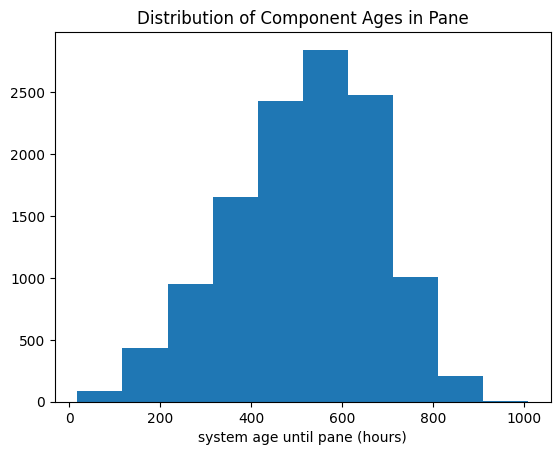

In [33]:
plt.hist(df[df.event_type=="failure"].component_age)
plt.xlabel("system age until pane (hours)")
plt.title("Distribution of Component Ages in Pane")
plt.show()

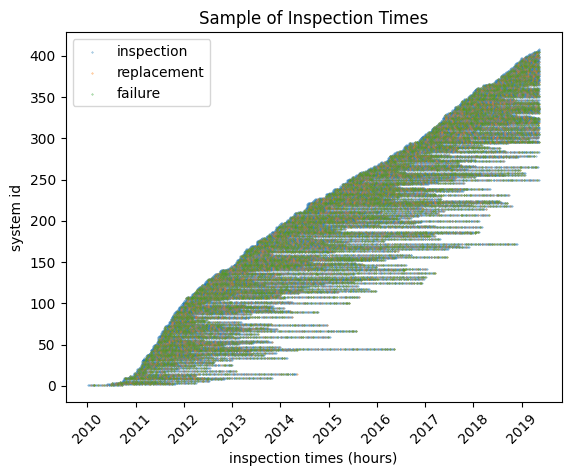

In [34]:
n_events_show = 50000
for e_type in df.event_type.unique():
    df_ = df[:n_events_show]
    df_ = df_[df_.event_type == e_type]
    plt.scatter(df_.event_date,
                df_.system_id,
                label=e_type,
                alpha=0.8, s=0.1)

plt.legend()
plt.xlabel("inspection times (hours)")
plt.ylabel("system id")
plt.xticks(rotation=45)
plt.title("Sample of Inspection Times")
plt.show()